# Proposed ConvNeXt-Base + SE Attention Pipeline for Olive Leaf Classification

**Single-run research notebook**

This notebook is the clean, paper-facing implementation of the proposed **ConvNeXt-Base + Squeeze-and-Excitation (SE) attention** pipeline. It intentionally runs **one training experiment per dataset** and removes the exploratory machinery from the development script (5-fold orchestration, repeated 10-run aggregation, alternative attention blocks, resume/state bookkeeping, and command-line handling).

### Experimental protocol preserved from the proposed Variation 2

- Backbone: **ImageNet-pretrained ConvNeXt-Base**
- Attention: **SE**, reduction ratio = **8**
- Input size: **224 × 224 RGB**
- Optimizer: **AdamW**, learning rate = **1e-4**, weight decay = **1e-2**
- Scheduler: **Cosine annealing**
- Maximum epochs: **50**
- Early stopping: **patience = 10**, monitored on validation accuracy
- Batch size: **16**
- Loss: **class-weighted cross-entropy** using inverse training-class frequency
- Split protocol: stratified **64% training / 16% validation / 20% test**
- Split seed and training seed: **1201**

The notebook displays and exports the dataset split distribution, training curves, test metrics, per-class metrics, and confusion matrix for each dataset, followed by a cross-dataset summary.

#### Authors: Morteza Farrokhnejad, Ali Farrokhnejad, Ali Hakan Ulusoy, Ahmet Rizaner

## 1. Imports and environment

 The cell below prints the main library versions used for the run.

In [1]:
from __future__ import annotations

import json
import os
import random
import time
import platform
from contextlib import nullcontext
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from IPython.display import display, Markdown
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ConvNeXt_Base_Weights, convnext_base

print(f"Python      : {platform.python_version()}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python      : 3.13.2
PyTorch     : 2.10.0+cu126
Torchvision : 0.25.0+cu126
NumPy       : 2.3.5
Pandas      : 2.3.3
scikit-learn: 1.8.0


## 2. Experiment configuration

**Edit only the dataset roots in this cell before execution.** The rest of the parameters encode the proposed pipeline and should remain fixed for a reproduction run.

Expected layouts:

- `kind="presplit"`: the root contains `train/`, `test/`, and optionally `val/`, `valid/`, or `validation/`, each containing one folder per class.
- `kind="flat"`: the root directly contains one folder per class.

For portability, relative paths are used rather than machine-specific absolute paths.

In [ ]:
# -----------------------------------------------------------------------------
# Paths: edit these five roots for the machine on which the notebook is run.
# -----------------------------------------------------------------------------
DATA_ROOT = Path("data")

DATASET_CONFIGS: List[Dict] = [
    {
        "name": "dataset1_oliver",
        "kind": "presplit",
        "root": #Specify this path
        "train_split_name": "train",
        "test_split_name": "test",
        "val_split_names": ["val", "valid", "validation"],
        "image_size": 224,
    },
    {
        "name": "dataset2_uguz",
        "kind": "presplit",
        "root": #Specify this path
        "train_split_name": "train",
        "test_split_name": "test",
        "val_split_names": ["val", "valid", "validation"],
        "image_size": 224,
    },
    {
        "name": "dataset3_diker",
        "kind": "flat",
        "root": #Specify this path
        "image_size": 224,
    },
    {
        "name": "dataset4_zeytin_augmented",
        "kind": "presplit",
        "root": #Specify this path
        "train_split_name": "train",
        "test_split_name": "test",
        "val_split_names": ["val", "valid", "validation"],
        "image_size": 224,
    },
    {
        "name": "dataset5_osco_mamani",
        "kind": "presplit",
        "root": #Specify this path
        "train_split_name": "train",
        "test_split_name": "test",
        "val_split_names": ["valid", "val", "validation"],
        "image_size": 224,
    },
]

# Proposed-model hyperparameters.
SEED = 1201
SPLIT_SEED = 1201
IMAGE_SIZE = 224
BATCH_SIZE = 16
MAX_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2
SE_REDUCTION = 8

NUM_WORKERS = 0 

RESULTS_DIR = Path("results_proposed_convnext_se_single_run")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

config_table = pd.DataFrame(
    [
        ("Backbone", "ConvNeXt-Base (ImageNet-1K pretrained)"),
        ("Attention", f"Squeeze-and-Excitation, reduction={SE_REDUCTION}"),
        ("Input", f"{IMAGE_SIZE}×{IMAGE_SIZE} RGB"),
        ("Split", "64% train / 16% validation / 20% test"),
        ("Split seed", SPLIT_SEED),
        ("Training seed", SEED),
        ("Batch size", BATCH_SIZE),
        ("Optimizer", "AdamW"),
        ("Learning rate", LEARNING_RATE),
        ("Weight decay", WEIGHT_DECAY),
        ("Scheduler", "CosineAnnealingLR"),
        ("Maximum epochs", MAX_EPOCHS),
        ("Early-stopping patience", PATIENCE),
        ("Loss", "Inverse-frequency class-weighted cross-entropy"),
    ],
    columns=["Setting", "Value"],
)
display(config_table)

,Setting,Value
0,Backbone,ConvNeXt-Base (ImageNet-1K pretrained)
1,Attention,"Squeeze-and-Excitation, reduction=8"
2,Input,224×224 RGB
3,Split,64% train / 16% validation / 20% test
4,Split seed,1201
5,Training seed,1201
6,Batch size,16
7,Optimizer,AdamW
8,Learning rate,0.0001
9,Weight decay,0.01


## 3. Reproducibility and hardware

A fixed seed is applied to Python, NumPy, and PyTorch. Deterministic CuDNN behavior is preferred here, since this notebook is intended as a reproduction artifact rather than a speed benchmark.

In [4]:
def set_reproducibility(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


set_reproducibility(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("CUDA GPU not detected; training will run on CPU.")

Device: cuda
GPU   : NVIDIA GeForce RTX 4070 Laptop GPU
VRAM  : 8.0 GB


## 4. Dataset discovery and fixed stratified split

The development script used repeated-holdout split as the fixed record split. It first reserves 20% of the pooled records for test data, then reserves 20% of the remaining 80% for validation, producing **64/16/20** overall.

In [5]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


@dataclass
class PooledDataset:
    dataset_name: str
    root: Path
    class_names: List[str]
    paths: np.ndarray
    labels: np.ndarray
    image_size: int


@dataclass
class SplitData:
    dataset_name: str
    root: Path
    class_names: List[str]
    train_paths: List[str]
    train_labels: np.ndarray
    val_paths: List[str]
    val_labels: np.ndarray
    test_paths: List[str]
    test_labels: np.ndarray
    image_size: int


def list_class_dirs(root: Path) -> List[str]:
    if not root.exists():
        raise FileNotFoundError(f"Dataset folder not found: {root.resolve()}")
    classes = sorted(p.name for p in root.iterdir() if p.is_dir())
    if not classes:
        raise RuntimeError(f"No class folders found under: {root.resolve()}")
    return classes


def collect_split_from_class_dirs(split_root: Path, class_names: List[str]) -> Tuple[List[str], np.ndarray]:
    paths: List[str] = []
    labels: List[int] = []
    for idx, class_name in enumerate(class_names):
        folder = split_root / class_name
        if not folder.exists():
            continue
        files = sorted(
            p for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        )
        paths.extend(str(p.resolve()) for p in files)
        labels.extend([idx] * len(files))
    return paths, np.asarray(labels, dtype=np.int64)


def resolve_validation_split(root: Path, names: Sequence[str]) -> Optional[Path]:
    for name in names:
        candidate = root / name
        if candidate.exists() and candidate.is_dir():
            return candidate
    return None


def can_stratify(y: np.ndarray) -> bool:
    if len(y) == 0:
        return False
    _, counts = np.unique(y, return_counts=True)
    return int(counts.min()) >= 2


def load_dataset_pool(cfg: Dict) -> PooledDataset:
    root = Path(cfg["root"])
    image_size = int(cfg.get("image_size", IMAGE_SIZE))
    all_paths: List[str] = []
    all_labels: List[int] = []

    if cfg["kind"] == "presplit":
        train_root = root / cfg.get("train_split_name", "train")
        class_names = list_class_dirs(train_root)

        source_roots = [train_root]
        test_root = root / cfg.get("test_split_name", "test")
        if test_root.exists():
            source_roots.append(test_root)
        val_root = resolve_validation_split(root, cfg.get("val_split_names", ["val", "valid", "validation"]))
        if val_root is not None:
            source_roots.append(val_root)

        # Preserve the original proposed-pipeline behavior: pool all available
        # source split folders before constructing the fixed 64/16/20 split.
        for source_root in source_roots:
            p, y = collect_split_from_class_dirs(source_root, class_names)
            all_paths.extend(p)
            all_labels.extend(y.tolist())

    elif cfg["kind"] == "flat":
        class_names = list_class_dirs(root)
        p, y = collect_split_from_class_dirs(root, class_names)
        all_paths.extend(p)
        all_labels.extend(y.tolist())
    else:
        raise ValueError(f"Unknown dataset kind: {cfg['kind']}")

    if not all_paths:
        raise RuntimeError(f"No supported images found for {cfg['name']} at {root.resolve()}")

    # Remove exact duplicate paths while preserving their original class labels.
    first_index_by_path: Dict[str, int] = {}
    for idx, path in enumerate(all_paths):
        first_index_by_path.setdefault(path, idx)
    keep = np.asarray(sorted(first_index_by_path.values()), dtype=int)

    paths = np.asarray(all_paths, dtype=object)[keep]
    labels = np.asarray(all_labels, dtype=np.int64)[keep]

    return PooledDataset(
        dataset_name=cfg["name"],
        root=root,
        class_names=class_names,
        paths=paths,
        labels=labels,
        image_size=image_size,
    )


def build_fixed_split(pool: PooledDataset, seed: int = SPLIT_SEED) -> SplitData:
    strat_all = pool.labels if can_stratify(pool.labels) else None
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        pool.paths,
        pool.labels,
        test_size=0.20,
        random_state=seed,
        stratify=strat_all,
    )

    strat_train_val = train_val_labels if can_stratify(train_val_labels) else None
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths,
        train_val_labels,
        test_size=0.20,
        random_state=seed,
        stratify=strat_train_val,
    )

    return SplitData(
        dataset_name=pool.dataset_name,
        root=pool.root,
        class_names=pool.class_names,
        train_paths=train_paths.tolist(),
        train_labels=train_labels,
        val_paths=val_paths.tolist(),
        val_labels=val_labels,
        test_paths=test_paths.tolist(),
        test_labels=test_labels,
        image_size=pool.image_size,
    )


def split_distribution(split: SplitData) -> pd.DataFrame:
    rows = []
    for split_name, labels in [
        ("Train", split.train_labels),
        ("Validation", split.val_labels),
        ("Test", split.test_labels),
    ]:
        counts = np.bincount(labels, minlength=len(split.class_names))
        for class_idx, count in enumerate(counts):
            rows.append(
                {
                    "Split": split_name,
                    "Class": split.class_names[class_idx],
                    "Count": int(count),
                }
            )
    return pd.DataFrame(rows)


def plot_split_distribution(split: SplitData, save_dir: Path) -> None:
    df = split_distribution(split)
    pivot = df.pivot(index="Class", columns="Split", values="Count").fillna(0)
    ax = pivot[["Train", "Validation", "Test"]].plot(kind="bar", figsize=(10, 5))
    ax.set_title(f"{split.dataset_name}: class distribution by split")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.savefig(save_dir / "split_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


def save_split_manifest(split: SplitData, save_dir: Path) -> None:
    rows = []
    for split_name, paths, labels in [
        ("train", split.train_paths, split.train_labels),
        ("validation", split.val_paths, split.val_labels),
        ("test", split.test_paths, split.test_labels),
    ]:
        for path, label in zip(paths, labels):
            p = Path(path)
            try:
                relative = p.relative_to(split.root.resolve())
            except Exception:
                relative = p.name
            rows.append(
                {
                    "dataset": split.dataset_name,
                    "split": split_name,
                    "relative_path": str(relative),
                    "label": int(label),
                    "class_name": split.class_names[int(label)],
                }
            )
    pd.DataFrame(rows).to_csv(save_dir / "split_manifest.csv", index=False)

## 5. Proposed model

The proposed architecture attaches a channel-wise **SE block** to the final ConvNeXt feature map, before global average pooling and the task-specific classifier. Only this attention mechanism is retained because the notebook represents the proposed model, not the earlier architecture search.

In [6]:
class SEModule(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch, channels, _, _ = x.shape
        weights = self.fc(x).view(batch, channels, 1, 1)
        return x * weights


class ProposedConvNeXtSE(nn.Module):
    def __init__(self, num_classes: int, se_reduction: int = SE_REDUCTION):
        super().__init__()
        backbone = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)
        channels = backbone.classifier[-1].in_features
        backbone.classifier[-1] = nn.Linear(channels, num_classes)

        self.features = backbone.features
        self.attention = SEModule(channels=channels, reduction=se_reduction)
        self.avgpool = backbone.avgpool
        self.classifier = backbone.classifier

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.attention(x)
        x = self.avgpool(x)
        return self.classifier(x)


def count_parameters(model: nn.Module) -> Tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# Architecture sanity check without training.
_demo_model = ProposedConvNeXtSE(num_classes=3)
_total, _trainable = count_parameters(_demo_model)
print(f"Model parameters (3-class head): {_total/1e6:.2f} M total, {_trainable/1e6:.2f} M trainable")
del _demo_model
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Model parameters (3-class head): 87.83 M total, 87.83 M trainable


## 6. Model preprocessing

Training augmentation is preserved from the source implementation: resize to 256×256, random 224×224 crop, horizontal and vertical flips, color jitter, and ±15° rotation. Validation and test images are deterministically resized to 224×224. All inputs use ImageNet normalization.

In [7]:
class ImagePathDataset(Dataset):
    def __init__(self, paths: List[str], labels: np.ndarray, class_names: List[str], transform=None):
        self.paths = list(paths)
        self.targets = [int(x) for x in labels]
        self.classes = list(class_names)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, self.targets[idx]


def get_transforms(image_size: int, train: bool):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    if train:
        return transforms.Compose(
            [
                transforms.Resize((image_size + 32, image_size + 32)),
                transforms.RandomCrop(image_size),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
                transforms.RandomRotation(15),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ]
        )

    return transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ]
    )


def make_loader(dataset: Dataset, batch_size: int, shuffle: bool = False) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

## 7. Training and evaluation

Early stopping follows validation accuracy, as in the source experiment. The best validation-accuracy weights are restored before the final test evaluation. Test data are never used for model selection.

The original development script labeled binary-class metrics as “macro” while internally using `average="binary"`. In this paper-facing notebook, `macro` and `weighted` mean exactly those averaging schemes for **all** datasets, including binary datasets. This fixes the label/implementation mismatch without changing the model or training pipeline.

In [8]:
def amp_context(device: torch.device):
    return torch.amp.autocast('cuda') if device.type == "cuda" else nullcontext()


def make_class_weights(labels: np.ndarray, num_classes: int, device: torch.device) -> torch.Tensor:
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    return torch.tensor(weights, dtype=torch.float32, device=device)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    scaler: GradScaler,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with amp_context(device):
            logits = model(images)
            loss = criterion(logits, labels)

        if device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    probabilities = []
    predictions = []
    targets = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels_device = labels.to(device, non_blocking=True)

        with amp_context(device):
            logits = model(images)
            loss = criterion(logits, labels_device)

        probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        total_loss += float(loss.item()) * images.size(0)
        probabilities.append(probs)
        predictions.append(preds)
        targets.append(labels.numpy())

    return (
        total_loss / len(loader.dataset),
        np.vstack(probabilities),
        np.concatenate(predictions),
        np.concatenate(targets),
    )


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


@dataclass
class RunOutput:
    metrics: Dict[str, float]
    class_report: pd.DataFrame
    confusion: np.ndarray
    history: pd.DataFrame
    y_true: np.ndarray
    y_pred: np.ndarray
    probabilities: np.ndarray
    best_epoch: int
    training_time_sec: float
    peak_gpu_memory_mb: float
    total_parameters: int
    trainable_parameters: int


def train_and_evaluate_once(split: SplitData, seed: int = SEED) -> RunOutput:
    set_reproducibility(seed)
    num_classes = len(split.class_names)

    train_ds = ImagePathDataset(
        split.train_paths, split.train_labels, split.class_names,
        transform=get_transforms(split.image_size, train=True),
    )
    val_ds = ImagePathDataset(
        split.val_paths, split.val_labels, split.class_names,
        transform=get_transforms(split.image_size, train=False),
    )
    test_ds = ImagePathDataset(
        split.test_paths, split.test_labels, split.class_names,
        transform=get_transforms(split.image_size, train=False),
    )

    train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(val_ds, BATCH_SIZE * 2, shuffle=False)
    test_loader = make_loader(test_ds, BATCH_SIZE * 2, shuffle=False)

    model = ProposedConvNeXtSE(num_classes=num_classes).to(DEVICE)
    total_parameters, trainable_parameters = count_parameters(model)

    class_weights = make_class_weights(split.train_labels, num_classes, DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

    best_val_accuracy = -np.inf
    best_epoch = 0
    best_weights = None
    epochs_without_improvement = 0
    history_rows = []

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    start_time = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_loss, _, val_pred, val_true = evaluate(model, val_loader, criterion, DEVICE)
        val_accuracy = accuracy_score(val_true, val_pred)
        val_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)
        current_lr = optimizer.param_groups[0]["lr"]

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "val_f1_macro": val_f1,
                "learning_rate": current_lr,
            }
        )

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_acc={val_accuracy:.4f} | val_macro_f1={val_f1:.4f}"
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = float(val_accuracy)
            best_epoch = epoch
            best_weights = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        scheduler.step()

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch}; best epoch = {best_epoch}.")
            break

    training_time_sec = time.perf_counter() - start_time

    if best_weights is None:
        raise RuntimeError("No best model weights were recorded.")
    model.load_state_dict(best_weights)

    _, probabilities, y_pred, y_true = evaluate(model, test_loader, criterion, DEVICE)
    metrics = compute_metrics(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=split.class_names,
        output_dict=True,
        zero_division=0,
    )
    class_report = pd.DataFrame(report).T

    peak_gpu_memory_mb = 0.0
    if DEVICE.type == "cuda":
        peak_gpu_memory_mb = torch.cuda.max_memory_allocated(DEVICE) / 1024**2

    history = pd.DataFrame(history_rows)

    del model, optimizer, scaler, best_weights
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return RunOutput(
        metrics=metrics,
        class_report=class_report,
        confusion=cm,
        history=history,
        y_true=y_true,
        y_pred=y_pred,
        probabilities=probabilities,
        best_epoch=best_epoch,
        training_time_sec=training_time_sec,
        peak_gpu_memory_mb=peak_gpu_memory_mb,
        total_parameters=total_parameters,
        trainable_parameters=trainable_parameters,
    )

## 8. Visualizations and result export

Each dataset run produces:

1. split-distribution figure,
2. loss curve,
3. validation accuracy / macro-F1 curve,
4. test metric table,
5. per-class classification report,
6. confusion matrix,
7. CSV files containing the exact split manifest, history, metrics, and class report.

In [9]:
def plot_training_history(history: pd.DataFrame, dataset_name: str, save_dir: Path) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training loss")
    plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name}: training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / "loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["val_accuracy"], marker="o", label="Validation accuracy")
    plt.plot(history["epoch"], history["val_f1_macro"], marker="o", label="Validation macro-F1")
    plt.ylim(0, 1.02)
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{dataset_name}: validation performance")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / "validation_metrics_curve.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_confusion(cm: np.ndarray, class_names: List[str], dataset_name: str, save_dir: Path) -> None:
    size = max(7, 1.2 * len(class_names) + 4)
    fig, ax = plt.subplots(figsize=(size, size * 0.85))
    image = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title=f"{dataset_name}: test confusion matrix",
    )
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")

    threshold = cm.max() / 2 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f"{cm[i, j]:d}",
                ha="center",
                va="center",
                fontsize=12,
                color="white" if cm[i, j] > threshold else "black",
            )

    fig.tight_layout()
    fig.savefig(save_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()


def metrics_frame(metrics: Dict[str, float]) -> pd.DataFrame:
    names = {
        "accuracy": "Accuracy",
        "precision_macro": "Precision (macro)",
        "recall_macro": "Recall (macro)",
        "f1_macro": "F1-score (macro)",
        "precision_weighted": "Precision (weighted)",
        "recall_weighted": "Recall (weighted)",
        "f1_weighted": "F1-score (weighted)",
    }
    return pd.DataFrame(
        [{"Metric": names[k], "Value": v} for k, v in metrics.items()]
    ).assign(Value=lambda df: df["Value"].round(6))


def save_run_outputs(split: SplitData, output: RunOutput, save_dir: Path) -> None:
    output.history.to_csv(save_dir / "training_history.csv", index=False)
    output.class_report.to_csv(save_dir / "classification_report.csv")
    pd.DataFrame(output.confusion, index=split.class_names, columns=split.class_names).to_csv(
        save_dir / "confusion_matrix.csv"
    )
    pd.DataFrame([output.metrics]).to_csv(save_dir / "test_metrics.csv", index=False)

    prediction_df = pd.DataFrame(
        {
            "true_label": output.y_true,
            "predicted_label": output.y_pred,
            "true_class": [split.class_names[i] for i in output.y_true],
            "predicted_class": [split.class_names[i] for i in output.y_pred],
        }
    )
    prediction_df.to_csv(save_dir / "test_predictions.csv", index=False)

## 9. Run the proposed pipeline once on each dataset

This is the training-execution cell. Each dataset is loaded, split once with the fixed seed, trained once, evaluated once on the held-out test set, visualized, and exported before moving to the next dataset.

A failed dataset stops the script rather than being silently skipped. For a submission artifact, partial success masquerading as a complete experiment would be a fairly creative definition of reproducibility.

### dataset1_oliver

Classes: 5
Class order: ['Euphyllura olivina (Milkweed Olive)', 'Froggattia olivinia (Lace Bug)', 'Healthy', 'Rust', 'Saissetia oleae (Black Scale)']
Records: total=3354 | train=2146 | validation=537 | test=671


Split,Test,Train,Validation
Class,,,
Euphyllura olivina (Milkweed Olive),106,339,85
Froggattia olivinia (Lace Bug),108,345,86
Healthy,226,723,181
Rust,109,350,87
Saissetia oleae (Black Scale),122,389,98


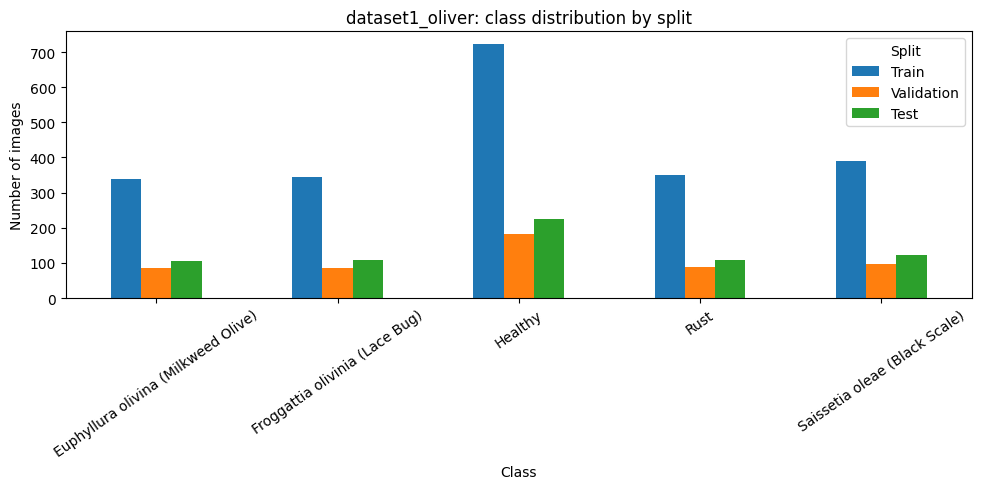

C:\Users\Asus\AppData\Local\Temp\ipykernel_10728\105819083.py:137: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))


Epoch 01/50 | train_loss=0.7574 | val_loss=0.2787 | val_acc=0.9088 | val_macro_f1=0.9089
Epoch 02/50 | train_loss=0.3430 | val_loss=0.3208 | val_acc=0.9162 | val_macro_f1=0.9176
Epoch 03/50 | train_loss=0.2640 | val_loss=0.1706 | val_acc=0.9367 | val_macro_f1=0.9389
Epoch 04/50 | train_loss=0.2004 | val_loss=0.2160 | val_acc=0.9292 | val_macro_f1=0.9300
Epoch 05/50 | train_loss=0.1726 | val_loss=0.1488 | val_acc=0.9460 | val_macro_f1=0.9473
Epoch 06/50 | train_loss=0.1715 | val_loss=0.1817 | val_acc=0.9441 | val_macro_f1=0.9462
Epoch 07/50 | train_loss=0.1283 | val_loss=0.1370 | val_acc=0.9590 | val_macro_f1=0.9581
Epoch 08/50 | train_loss=0.1670 | val_loss=0.1935 | val_acc=0.9348 | val_macro_f1=0.9367
Epoch 09/50 | train_loss=0.1293 | val_loss=0.1421 | val_acc=0.9385 | val_macro_f1=0.9426
Epoch 10/50 | train_loss=0.1425 | val_loss=0.1550 | val_acc=0.9479 | val_macro_f1=0.9493
Epoch 11/50 | train_loss=0.1147 | val_loss=0.1365 | val_acc=0.9572 | val_macro_f1=0.9586
Epoch 12/50 | train_l

#### Test-set metrics

,Metric,Value
0,Accuracy,0.967213
1,Precision (macro),0.974482
2,Recall (macro),0.963626
3,F1-score (macro),0.968241
4,Precision (weighted),0.967954
5,Recall (weighted),0.967213
6,F1-score (weighted),0.966715


#### Per-class report

,precision,recall,f1-score,support
Euphyllura olivina (Milkweed Olive),0.9815,1.0000,0.9907,106.0000
Froggattia olivinia (Lace Bug),0.9810,0.9537,0.9671,108.0000
Healthy,0.9375,0.9956,0.9657,226.0000
Rust,1.0000,1.0000,1.0000,109.0000
Saissetia oleae (Black Scale),0.9725,0.8689,0.9177,122.0000
accuracy,0.9672,0.9672,0.9672,0.9672
macro avg,0.9745,0.9636,0.9682,671.0000
weighted avg,0.9680,0.9672,0.9667,671.0000


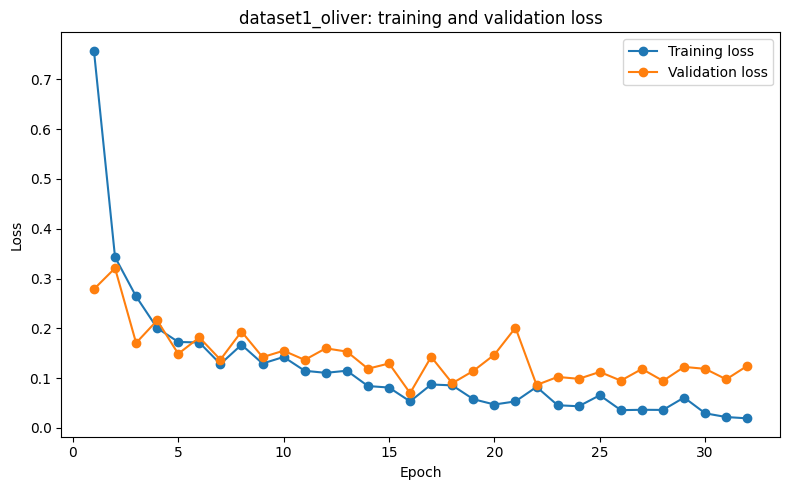

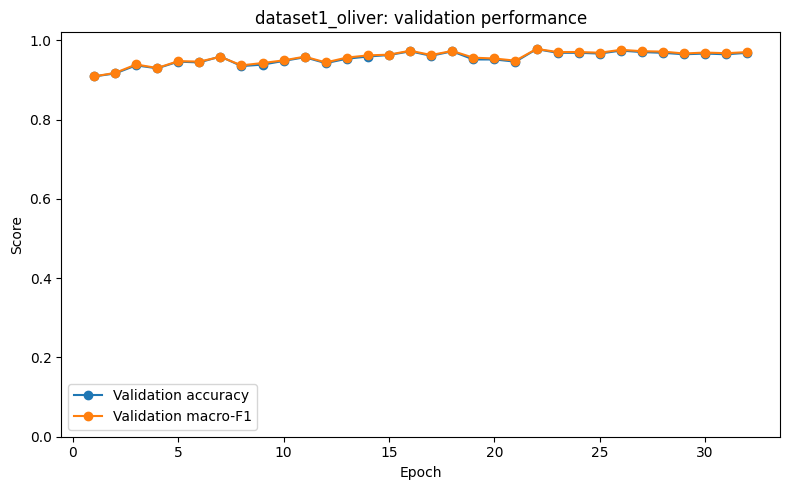

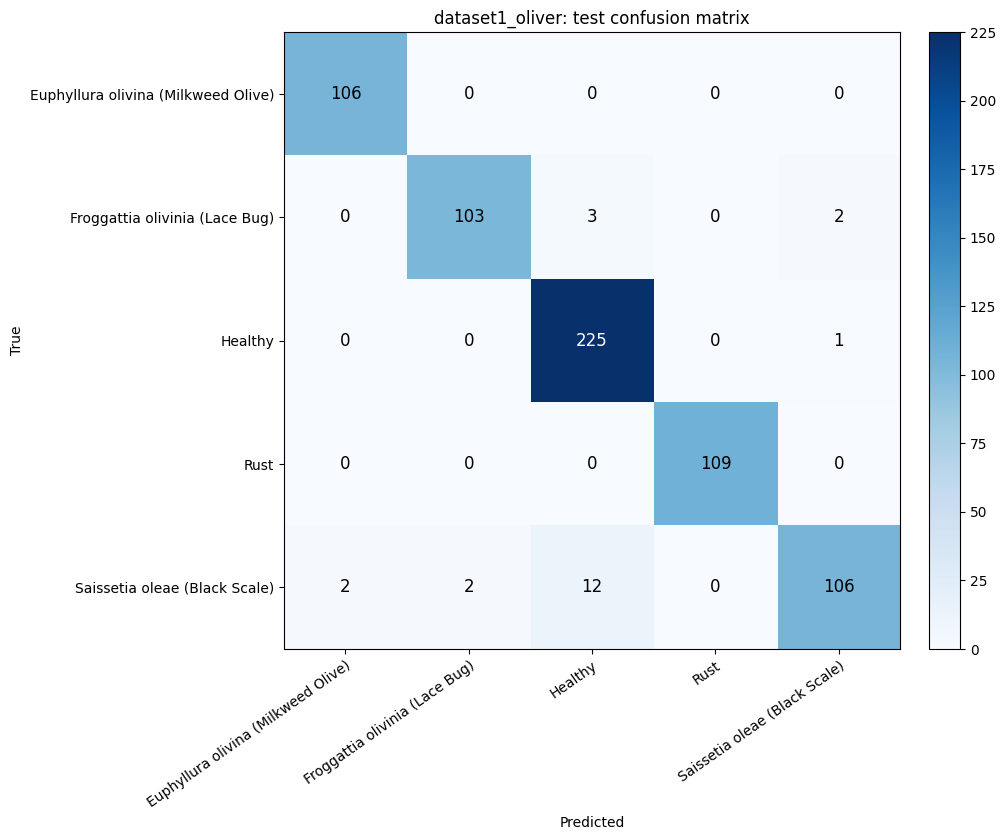

Completed dataset1_oliver: accuracy=0.9672, macro-F1=0.9682, best_epoch=22, training_time=18.1 min


### dataset2_uguz

Classes: 3
Class order: ['Healthy', 'aculus_olearius', 'olive_peacock_spot']
Records: total=3400 | train=2176 | validation=544 | test=680


Split,Test,Train,Validation
Class,,,
Healthy,210,672,168
aculus_olearius,178,570,142
olive_peacock_spot,292,934,234


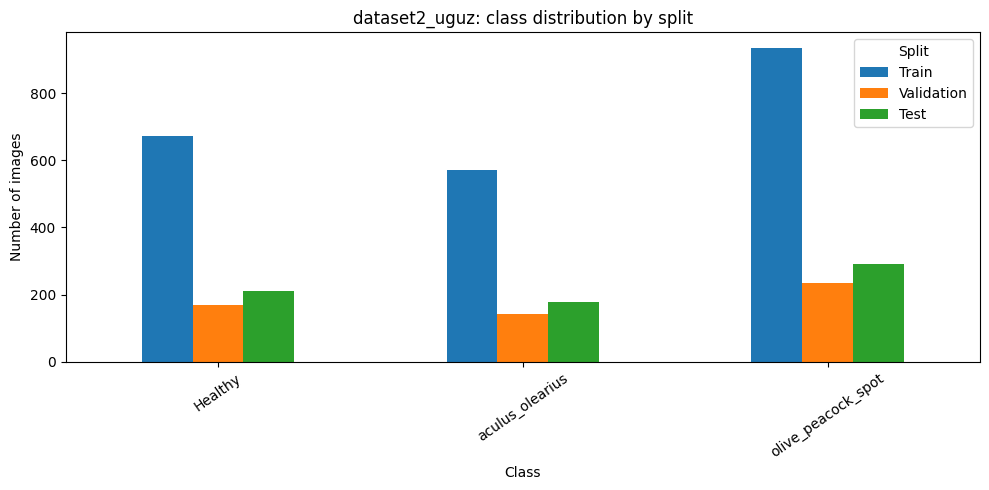

C:\Users\Asus\AppData\Local\Temp\ipykernel_10728\105819083.py:137: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))


Epoch 01/50 | train_loss=0.2555 | val_loss=0.0790 | val_acc=0.9816 | val_macro_f1=0.9815
Epoch 02/50 | train_loss=0.1223 | val_loss=0.0438 | val_acc=0.9871 | val_macro_f1=0.9871
Epoch 03/50 | train_loss=0.0840 | val_loss=0.0349 | val_acc=0.9908 | val_macro_f1=0.9902
Epoch 04/50 | train_loss=0.0657 | val_loss=0.0877 | val_acc=0.9577 | val_macro_f1=0.9597
Epoch 05/50 | train_loss=0.0557 | val_loss=0.0374 | val_acc=0.9853 | val_macro_f1=0.9843
Epoch 06/50 | train_loss=0.0653 | val_loss=0.1084 | val_acc=0.9485 | val_macro_f1=0.9492
Epoch 07/50 | train_loss=0.0569 | val_loss=0.0577 | val_acc=0.9890 | val_macro_f1=0.9890
Epoch 08/50 | train_loss=0.0483 | val_loss=0.0572 | val_acc=0.9779 | val_macro_f1=0.9786
Epoch 09/50 | train_loss=0.0601 | val_loss=0.0418 | val_acc=0.9890 | val_macro_f1=0.9890
Epoch 10/50 | train_loss=0.0442 | val_loss=0.0272 | val_acc=0.9853 | val_macro_f1=0.9852
Epoch 11/50 | train_loss=0.0264 | val_loss=0.0286 | val_acc=0.9871 | val_macro_f1=0.9865
Epoch 12/50 | train_l

#### Test-set metrics

,Metric,Value
0,Accuracy,0.983824
1,Precision (macro),0.982827
2,Recall (macro),0.983752
3,F1-score (macro),0.983219
4,Precision (weighted),0.983989
5,Recall (weighted),0.983824
6,F1-score (weighted),0.983846


#### Per-class report

,precision,recall,f1-score,support
Healthy,0.9951,0.9762,0.9856,210.0000
aculus_olearius,0.9670,0.9888,0.9778,178.0000
olive_peacock_spot,0.9863,0.9863,0.9863,292.0000
accuracy,0.9838,0.9838,0.9838,0.9838
macro avg,0.9828,0.9838,0.9832,680.0000
weighted avg,0.9840,0.9838,0.9838,680.0000


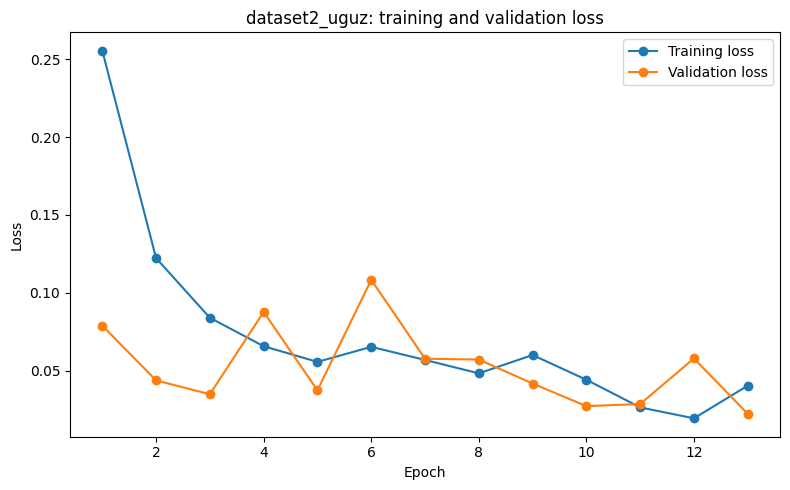

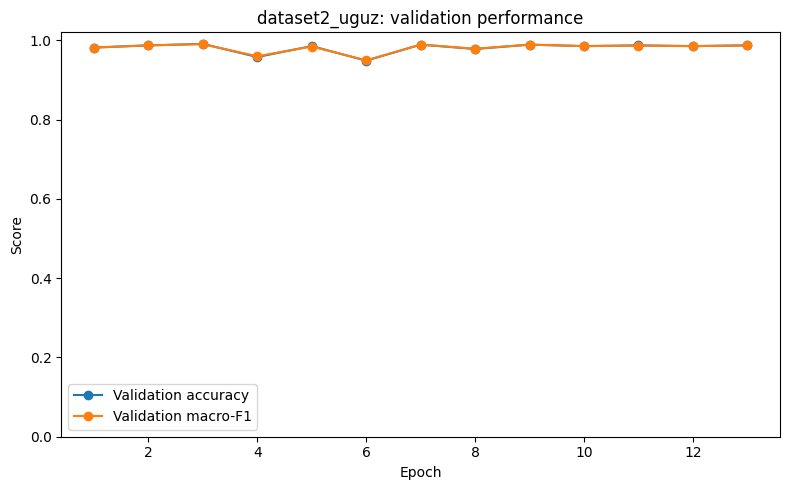

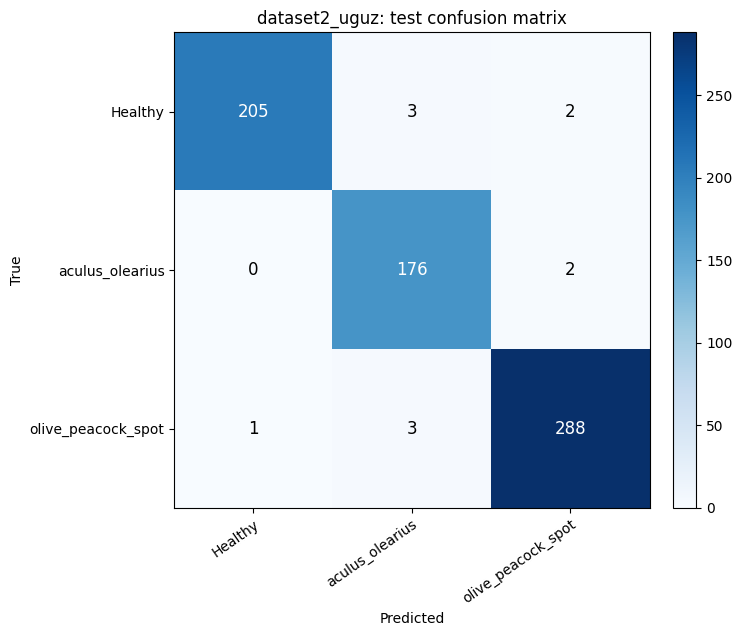

Completed dataset2_uguz: accuracy=0.9838, macro-F1=0.9832, best_epoch=3, training_time=8.9 min


### dataset3_diker

Classes: 2
Class order: ['Healthy', 'Ill']
Records: total=954 | train=610 | validation=153 | test=191


Split,Test,Train,Validation
Class,,,
Healthy,115,365,92
Ill,76,245,61


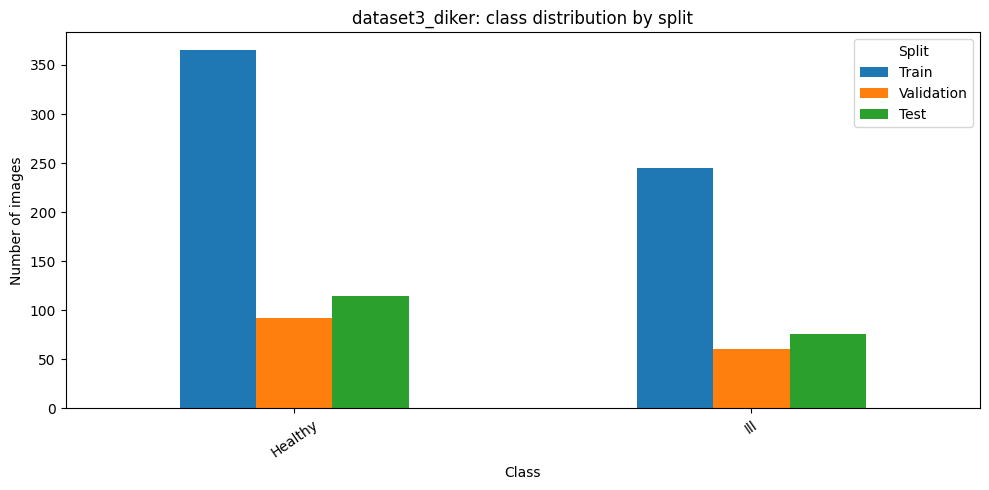

C:\Users\Asus\AppData\Local\Temp\ipykernel_10728\105819083.py:137: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))


Epoch 01/50 | train_loss=0.2072 | val_loss=0.0353 | val_acc=0.9935 | val_macro_f1=0.9932
Epoch 02/50 | train_loss=0.0675 | val_loss=0.0087 | val_acc=1.0000 | val_macro_f1=1.0000
Epoch 03/50 | train_loss=0.0406 | val_loss=0.0028 | val_acc=1.0000 | val_macro_f1=1.0000
Epoch 04/50 | train_loss=0.0290 | val_loss=0.0522 | val_acc=0.9935 | val_macro_f1=0.9932
Epoch 05/50 | train_loss=0.0435 | val_loss=0.0318 | val_acc=0.9935 | val_macro_f1=0.9932
Epoch 06/50 | train_loss=0.0348 | val_loss=0.0243 | val_acc=0.9935 | val_macro_f1=0.9932
Epoch 07/50 | train_loss=0.0286 | val_loss=0.0028 | val_acc=1.0000 | val_macro_f1=1.0000
Epoch 08/50 | train_loss=0.0223 | val_loss=0.0121 | val_acc=1.0000 | val_macro_f1=1.0000
Epoch 09/50 | train_loss=0.0259 | val_loss=0.0158 | val_acc=0.9935 | val_macro_f1=0.9932
Epoch 10/50 | train_loss=0.0298 | val_loss=0.0282 | val_acc=0.9935 | val_macro_f1=0.9932
Epoch 11/50 | train_loss=0.0190 | val_loss=0.0037 | val_acc=1.0000 | val_macro_f1=1.0000
Epoch 12/50 | train_l

#### Test-set metrics

,Metric,Value
0,Accuracy,0.994764
1,Precision (macro),0.993506
2,Recall (macro),0.995652
3,F1-score (macro),0.994549
4,Precision (weighted),0.994832
5,Recall (weighted),0.994764
6,F1-score (weighted),0.994770


#### Per-class report

,precision,recall,f1-score,support
Healthy,1.0000,0.9913,0.9956,115.0000
Ill,0.9870,1.0000,0.9935,76.0000
accuracy,0.9948,0.9948,0.9948,0.9948
macro avg,0.9935,0.9957,0.9945,191.0000
weighted avg,0.9948,0.9948,0.9948,191.0000


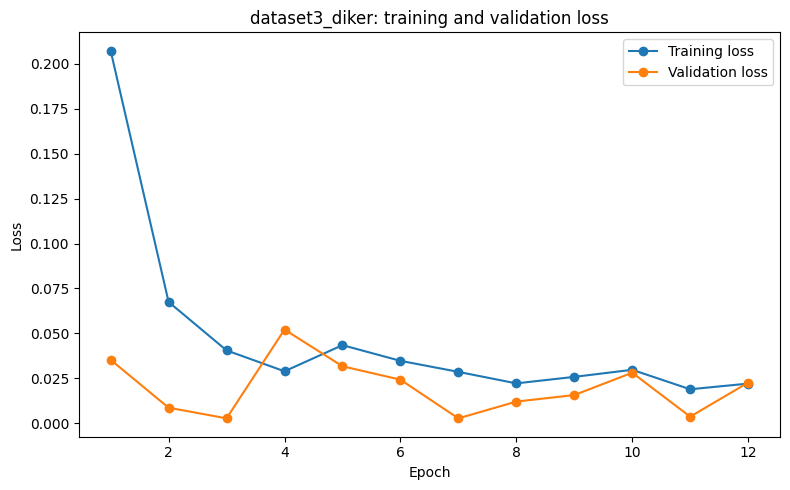

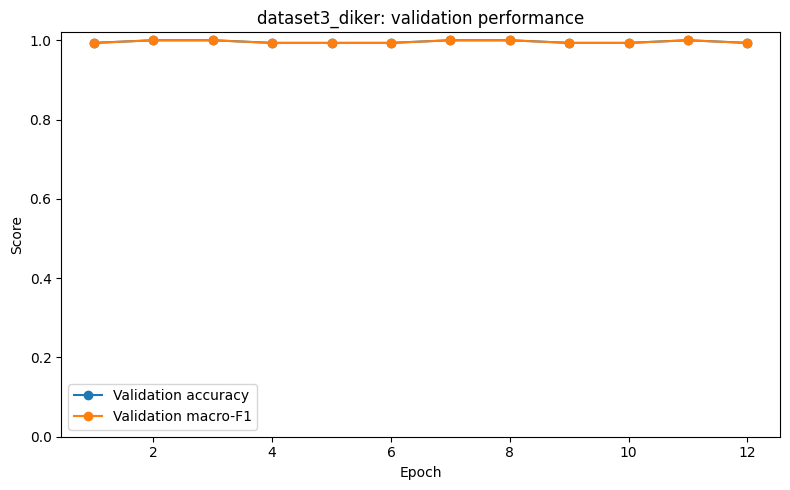

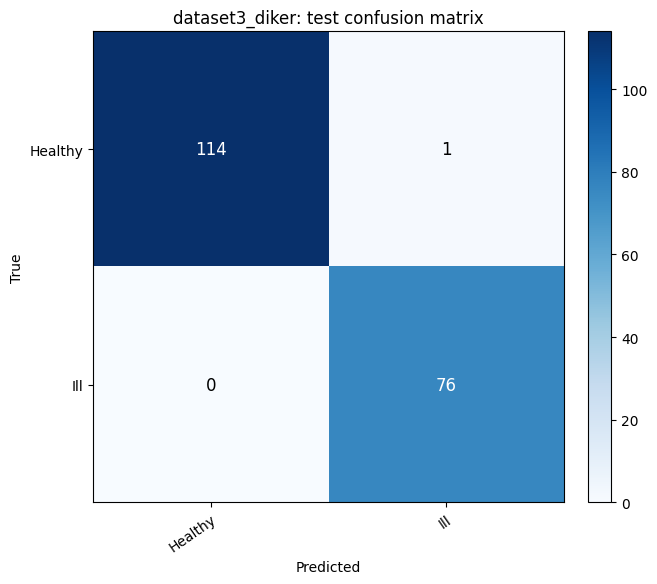

Completed dataset3_diker: accuracy=0.9948, macro-F1=0.9945, best_epoch=2, training_time=5.4 min


### dataset4_zeytin_augmented

Classes: 3
Class order: ['healthy', 'peacock-eye', 'rust-pest']
Records: total=6961 | train=4454 | validation=1114 | test=1393


Split,Test,Train,Validation
Class,,,
healthy,385,1233,308
peacock-eye,652,2084,521
rust-pest,356,1137,285


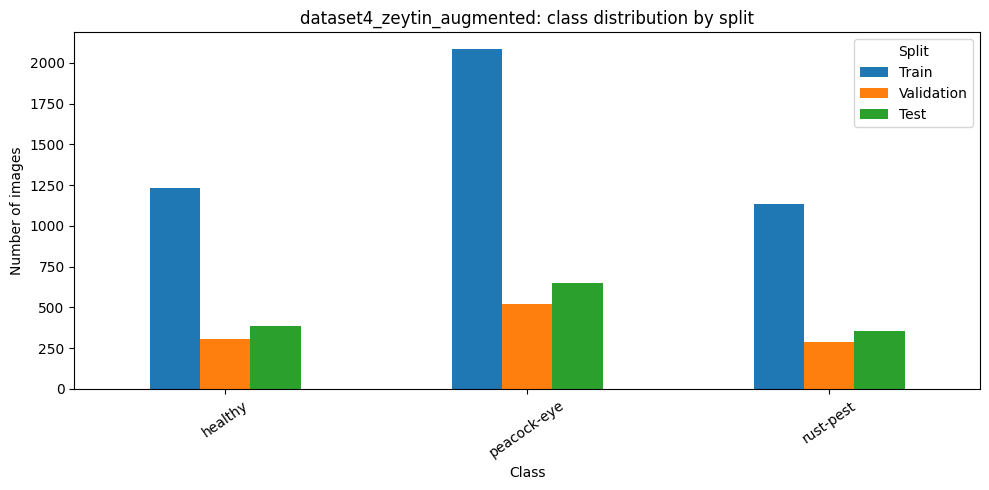

C:\Users\Asus\AppData\Local\Temp\ipykernel_10728\105819083.py:137: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))


Epoch 01/50 | train_loss=0.2330 | val_loss=0.1210 | val_acc=0.9497 | val_macro_f1=0.9481
Epoch 02/50 | train_loss=0.0958 | val_loss=0.1645 | val_acc=0.9479 | val_macro_f1=0.9448
Epoch 03/50 | train_loss=0.0762 | val_loss=0.1179 | val_acc=0.9515 | val_macro_f1=0.9515
Epoch 04/50 | train_loss=0.0739 | val_loss=0.0943 | val_acc=0.9668 | val_macro_f1=0.9665
Epoch 05/50 | train_loss=0.0569 | val_loss=0.0606 | val_acc=0.9767 | val_macro_f1=0.9769
Epoch 06/50 | train_loss=0.0443 | val_loss=0.0850 | val_acc=0.9713 | val_macro_f1=0.9706
Epoch 07/50 | train_loss=0.0579 | val_loss=0.0698 | val_acc=0.9794 | val_macro_f1=0.9787
Epoch 08/50 | train_loss=0.0383 | val_loss=0.1059 | val_acc=0.9596 | val_macro_f1=0.9591
Epoch 09/50 | train_loss=0.0385 | val_loss=0.0956 | val_acc=0.9695 | val_macro_f1=0.9667
Epoch 10/50 | train_loss=0.0379 | val_loss=0.0597 | val_acc=0.9785 | val_macro_f1=0.9778
Epoch 11/50 | train_loss=0.0385 | val_loss=0.0680 | val_acc=0.9803 | val_macro_f1=0.9799
Epoch 12/50 | train_l

#### Test-set metrics

,Metric,Value
0,Accuracy,0.992821
1,Precision (macro),0.993763
2,Recall (macro),0.992124
3,F1-score (macro),0.992934
4,Precision (weighted),0.992842
5,Recall (weighted),0.992821
6,F1-score (weighted),0.992822


#### Per-class report

,precision,recall,f1-score,support
healthy,0.9948,0.9922,0.9935,385.0000
peacock-eye,0.9893,0.9954,0.9924,652.0000
rust-pest,0.9972,0.9888,0.9929,356.0000
accuracy,0.9928,0.9928,0.9928,0.9928
macro avg,0.9938,0.9921,0.9929,1393.0000
weighted avg,0.9928,0.9928,0.9928,1393.0000


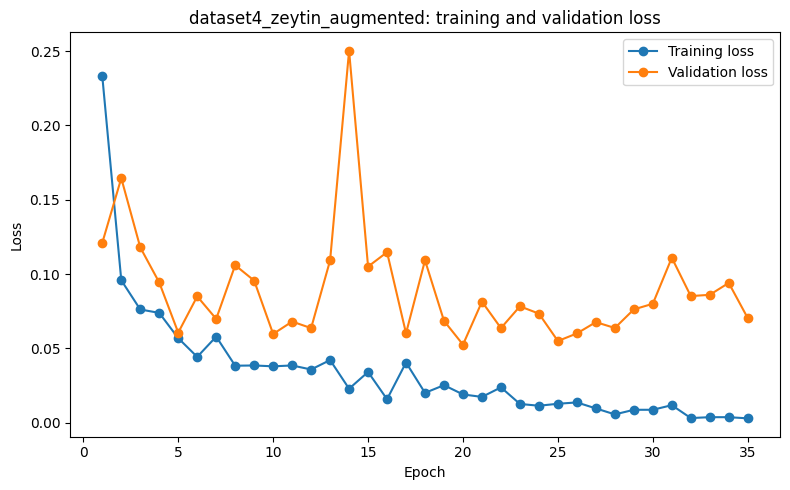

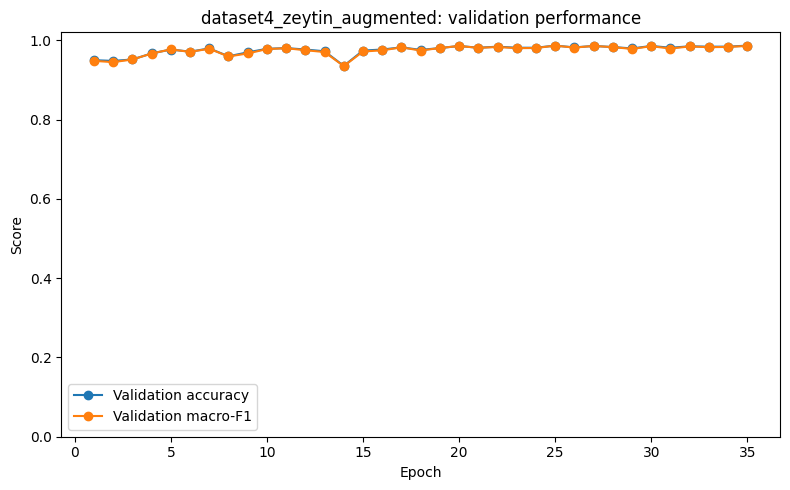

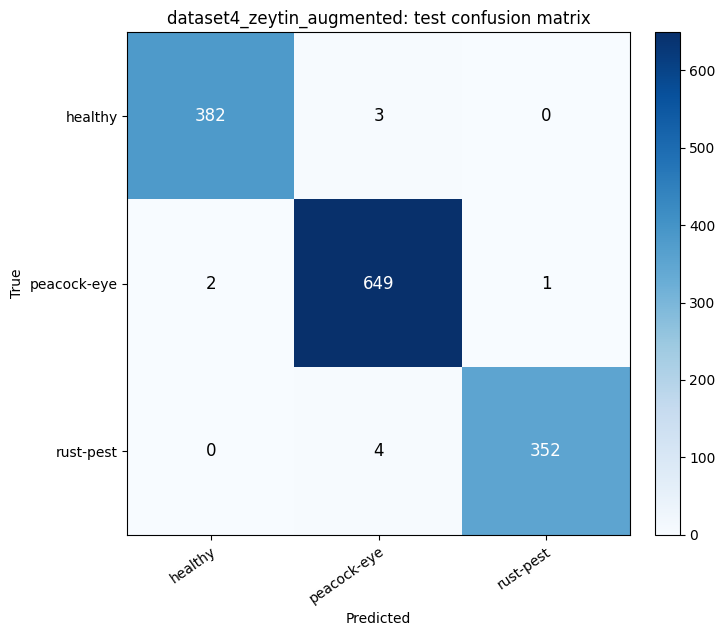

Completed dataset4_zeytin_augmented: accuracy=0.9928, macro-F1=0.9929, best_epoch=25, training_time=39.0 min


### dataset5_osco_mamani

Classes: 3
Class order: ['deficiencia', 'negrilla', 'virosis']
Records: total=773 | train=494 | validation=124 | test=155


Split,Test,Train,Validation
Class,,,
deficiencia,52,165,41
negrilla,51,164,42
virosis,52,165,41


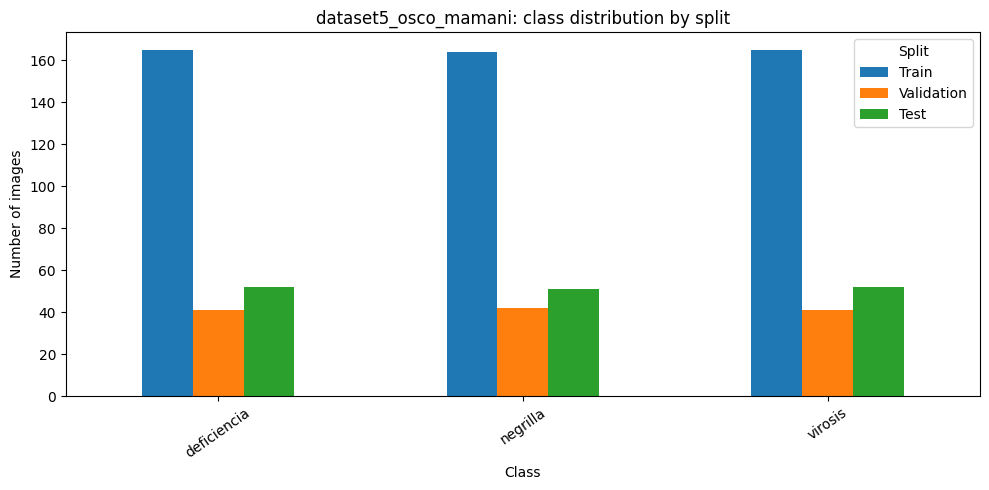

C:\Users\Asus\AppData\Local\Temp\ipykernel_10728\105819083.py:137: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))


Epoch 01/50 | train_loss=0.5079 | val_loss=0.2131 | val_acc=0.9032 | val_macro_f1=0.9027
Epoch 02/50 | train_loss=0.1777 | val_loss=0.1588 | val_acc=0.9274 | val_macro_f1=0.9278
Epoch 03/50 | train_loss=0.1011 | val_loss=0.1613 | val_acc=0.9274 | val_macro_f1=0.9267
Epoch 04/50 | train_loss=0.0808 | val_loss=0.1272 | val_acc=0.9355 | val_macro_f1=0.9353
Epoch 05/50 | train_loss=0.0508 | val_loss=0.1673 | val_acc=0.9274 | val_macro_f1=0.9272
Epoch 06/50 | train_loss=0.0409 | val_loss=0.1450 | val_acc=0.9194 | val_macro_f1=0.9200
Epoch 07/50 | train_loss=0.0478 | val_loss=0.2577 | val_acc=0.9355 | val_macro_f1=0.9358
Epoch 08/50 | train_loss=0.0482 | val_loss=0.1546 | val_acc=0.9758 | val_macro_f1=0.9758
Epoch 09/50 | train_loss=0.0349 | val_loss=0.1852 | val_acc=0.9597 | val_macro_f1=0.9592
Epoch 10/50 | train_loss=0.0646 | val_loss=0.1773 | val_acc=0.9435 | val_macro_f1=0.9430
Epoch 11/50 | train_loss=0.0376 | val_loss=0.1693 | val_acc=0.9516 | val_macro_f1=0.9516
Epoch 12/50 | train_l

#### Test-set metrics

,Metric,Value
0,Accuracy,0.961290
1,Precision (macro),0.961703
2,Recall (macro),0.961036
3,F1-score (macro),0.961132
4,Precision (weighted),0.961719
5,Recall (weighted),0.961290
6,F1-score (weighted),0.961268


#### Per-class report

,precision,recall,f1-score,support
deficiencia,1.0000,1.0000,1.0000,52.0000
negrilla,0.9592,0.9216,0.9400,51.0000
virosis,0.9259,0.9615,0.9434,52.0000
accuracy,0.9613,0.9613,0.9613,0.9613
macro avg,0.9617,0.9610,0.9611,155.0000
weighted avg,0.9617,0.9613,0.9613,155.0000


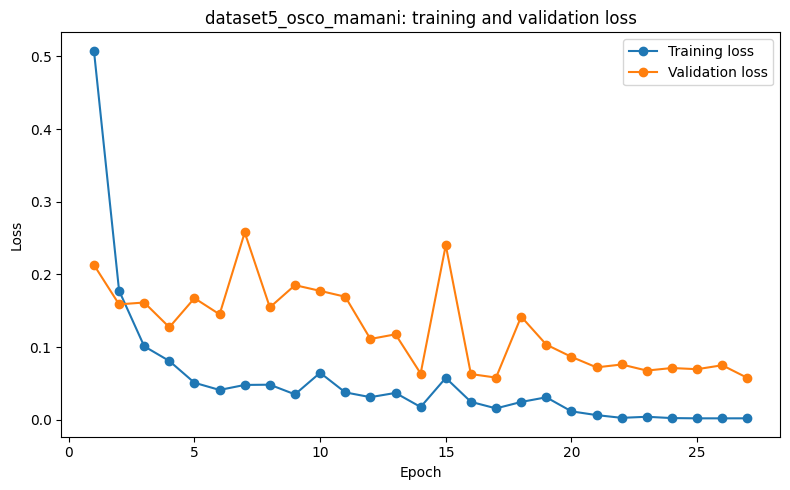

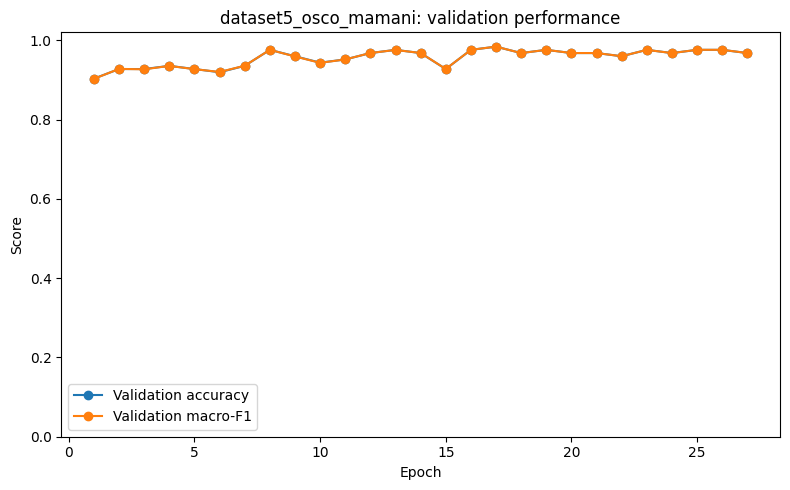

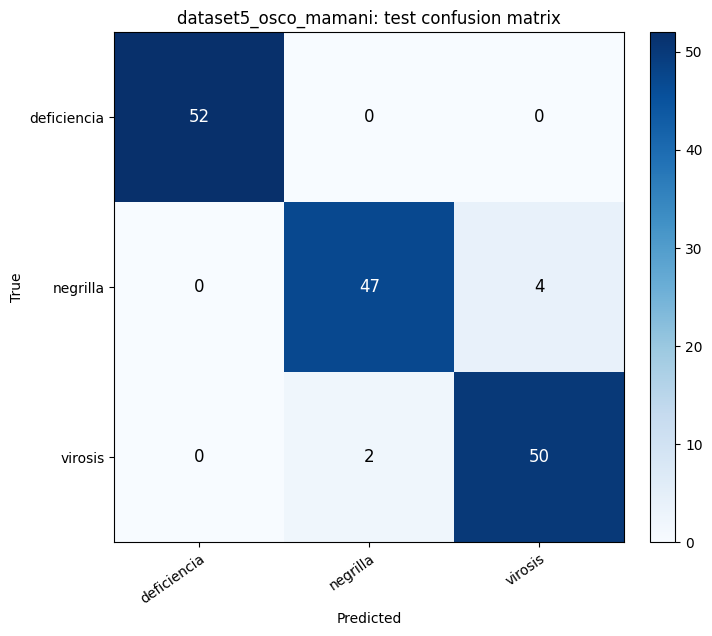

Completed dataset5_osco_mamani: accuracy=0.9613, macro-F1=0.9611, best_epoch=17, training_time=3.4 min


In [10]:
all_results: List[Dict] = []

for cfg in DATASET_CONFIGS:
    dataset_name = cfg["name"]
    save_dir = RESULTS_DIR / dataset_name
    save_dir.mkdir(parents=True, exist_ok=True)

    display(Markdown(f"### {dataset_name}"))

    pool = load_dataset_pool(cfg)
    split = build_fixed_split(pool, seed=SPLIT_SEED)
    save_split_manifest(split, save_dir)

    print(f"Classes: {len(split.class_names)}")
    print(f"Class order: {split.class_names}")
    print(
        f"Records: total={len(pool.paths)} | "
        f"train={len(split.train_paths)} | validation={len(split.val_paths)} | test={len(split.test_paths)}"
    )

    distribution_df = split_distribution(split)
    display(distribution_df.pivot(index="Class", columns="Split", values="Count").fillna(0).astype(int))
    plot_split_distribution(split, save_dir)

    output = train_and_evaluate_once(split, seed=SEED)
    save_run_outputs(split, output, save_dir)

    display(Markdown("#### Test-set metrics"))
    display(metrics_frame(output.metrics))

    display(Markdown("#### Per-class report"))
    display(output.class_report.round(4))

    plot_training_history(output.history, dataset_name, save_dir)
    plot_confusion(output.confusion, split.class_names, dataset_name, save_dir)

    all_results.append(
        {
            "dataset": dataset_name,
            "num_classes": len(split.class_names),
            "num_train": len(split.train_paths),
            "num_validation": len(split.val_paths),
            "num_test": len(split.test_paths),
            "best_epoch": output.best_epoch,
            "training_time_sec": output.training_time_sec,
            "peak_gpu_memory_mb": output.peak_gpu_memory_mb,
            "total_parameters": output.total_parameters,
            "trainable_parameters": output.trainable_parameters,
            **output.metrics,
        }
    )

    print(
        f"Completed {dataset_name}: "
        f"accuracy={output.metrics['accuracy']:.4f}, "
        f"macro-F1={output.metrics['f1_macro']:.4f}, "
        f"best_epoch={output.best_epoch}, "
        f"training_time={output.training_time_sec/60:.1f} min"
    )

## 10. Cross-dataset summary

The final cell collects the one-run results into a compact table suitable for checking the values and exports it as `single_run_summary.csv`. The accompanying figure compares the four primary test metrics across datasets.

,dataset,num_classes,num_train,num_validation,num_test,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,best_epoch,training_time_sec,peak_gpu_memory_mb
0,dataset1_oliver,5,2146,537,671,0.9672,0.9745,0.9636,0.9682,0.9667,22,1086.7803,3550.8257
1,dataset2_uguz,3,2176,544,680,0.9838,0.9828,0.9838,0.9832,0.9838,3,536.3968,3548.7866
2,dataset3_diker,2,610,153,191,0.9948,0.9935,0.9957,0.9945,0.9948,2,322.9389,3547.8296
3,dataset4_zeytin_augmented,3,4454,1114,1393,0.9928,0.9938,0.9921,0.9929,0.9928,25,2337.3484,3546.3179
4,dataset5_osco_mamani,3,494,124,155,0.9613,0.9617,0.9610,0.9611,0.9613,17,206.7571,3541.8179


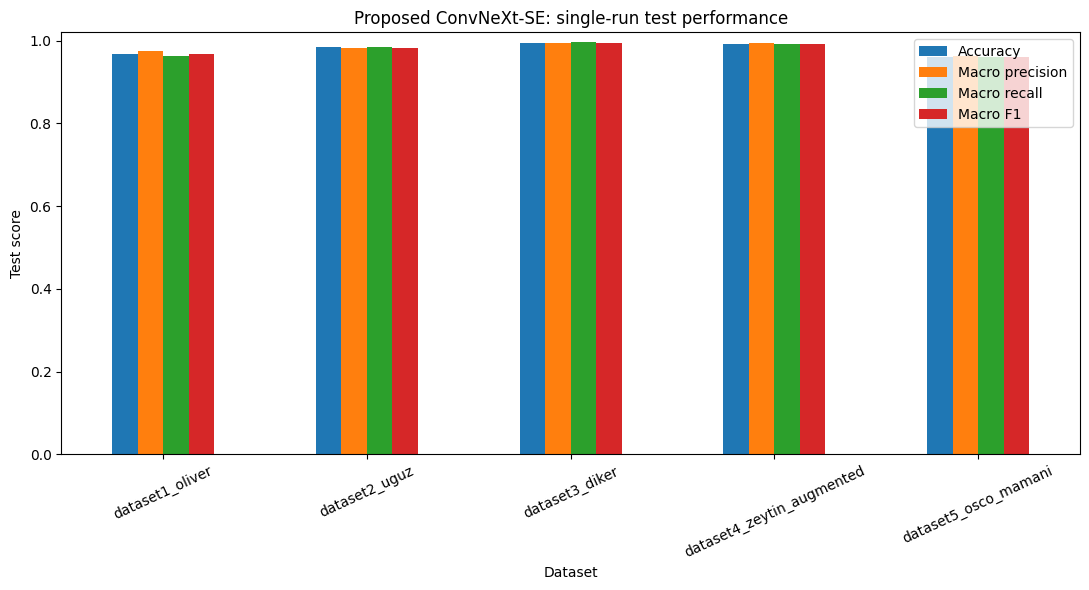

All outputs saved under: C:\Users\Asus\Desktop\Work\Olive Leaf Disease Detection\Code\results_proposed_convnext_se_single_run


In [11]:
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(RESULTS_DIR / "single_run_summary.csv", index=False)

paper_columns = [
    "dataset",
    "num_classes",
    "num_train",
    "num_validation",
    "num_test",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
    "best_epoch",
    "training_time_sec",
    "peak_gpu_memory_mb",
]

display(summary_df[paper_columns].round(4))

metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
plot_df = summary_df.set_index("dataset")[metrics_to_plot]
ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_ylim(0, 1.02)
ax.set_xlabel("Dataset")
ax.set_ylabel("Test score")
ax.set_title("Proposed ConvNeXt-SE: single-run test performance")
ax.tick_params(axis="x", rotation=25)
ax.legend(["Accuracy", "Macro precision", "Macro recall", "Macro F1"])
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cross_dataset_test_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"All outputs saved under: {RESULTS_DIR.resolve()}")